# Bitcoin Price Prediction 

Predicting a signal that indicates whether buying a particular stock will be helpful or not

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
from xgboost import XGBRegressor

# ========================
# TIME SERIES MODELS
# ========================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


import warnings
warnings.filterwarnings('ignore')

## Importing and Reading Dataset

In [3]:
bitcoin_pred = pd.read_csv('../Dataset/bitcoin.csv')

In [4]:
bitcoin_pred.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## Summary Statistics

In [5]:
bitcoin_pred.shape

(2713, 7)

In [6]:
bitcoin_pred.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [7]:
bitcoin_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


## Checking for missing values

In [8]:
bitcoin_pred.isnull().sum().sort_values(ascending=False)

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

## Exploratory Data Analysis

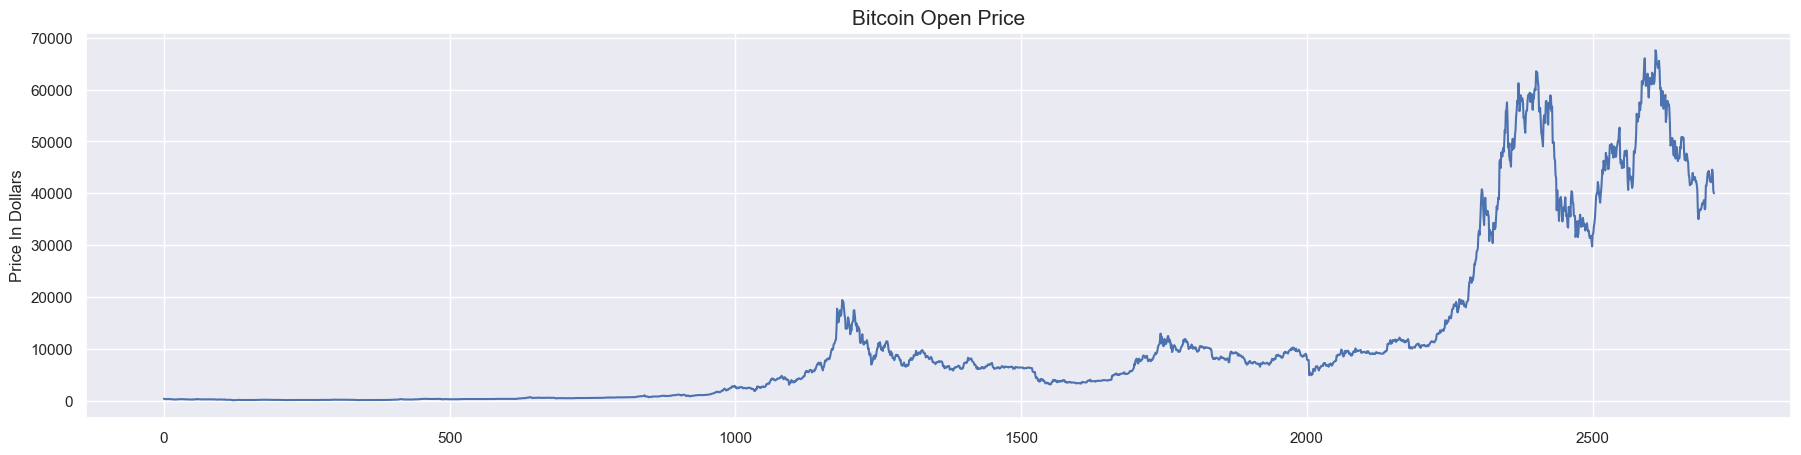

In [9]:
plt.figure(figsize=(22, 5))
plt.plot(bitcoin_pred['Open'])
plt.title('Bitcoin Open Price', fontsize = 15)
plt.ylabel('Price In Dollars')
plt.show()

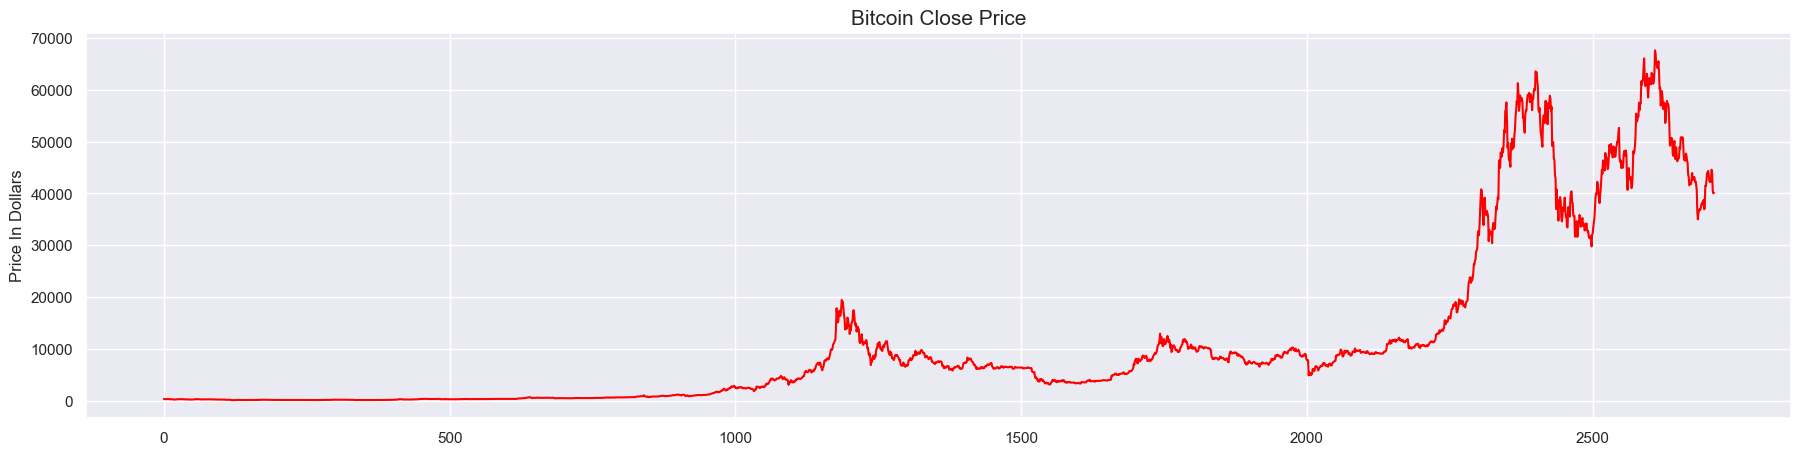

In [10]:
plt.figure(figsize=(22, 5))
plt.plot(bitcoin_pred['Close'], color='red')
plt.title('Bitcoin Close Price', fontsize=15)
plt.ylabel('Price In Dollars')
plt.show()

The prices of bitcoin stocks are showing upward trend as depicted by the plot

In [11]:
bitcoin_pred[bitcoin_pred['Close'] == bitcoin_pred['Adj Close']].shape, bitcoin_pred.shape

((2713, 7), (2713, 7))

## Removing Redundant Data in the Dataset

Since `Close` and `Adj Close` Have the same data, we would have to drop `Adj Close`

In [12]:
bitcoin_pred = bitcoin_pred.drop(['Adj Close'], axis=1)
bitcoin_pred.head()

,Date,Open,High,Low,Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


## Visualization with Subplot Distribution

In [13]:
features = ['Open', 'Close', 'High', 'Low']

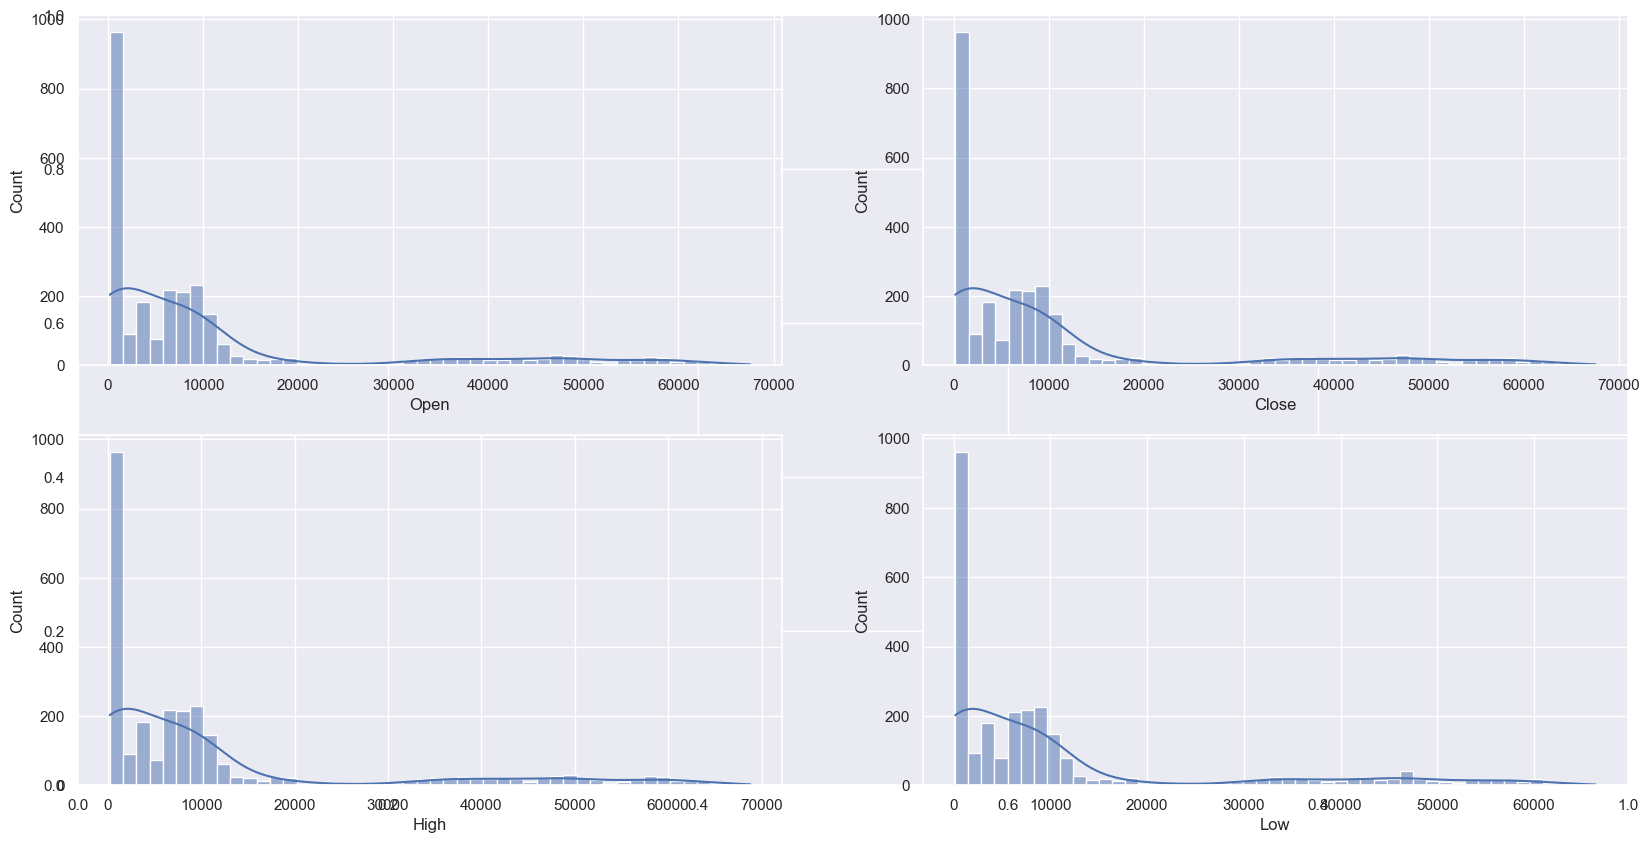

In [14]:
plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.histplot(bitcoin_pred[col], kde=True)
plt.show()

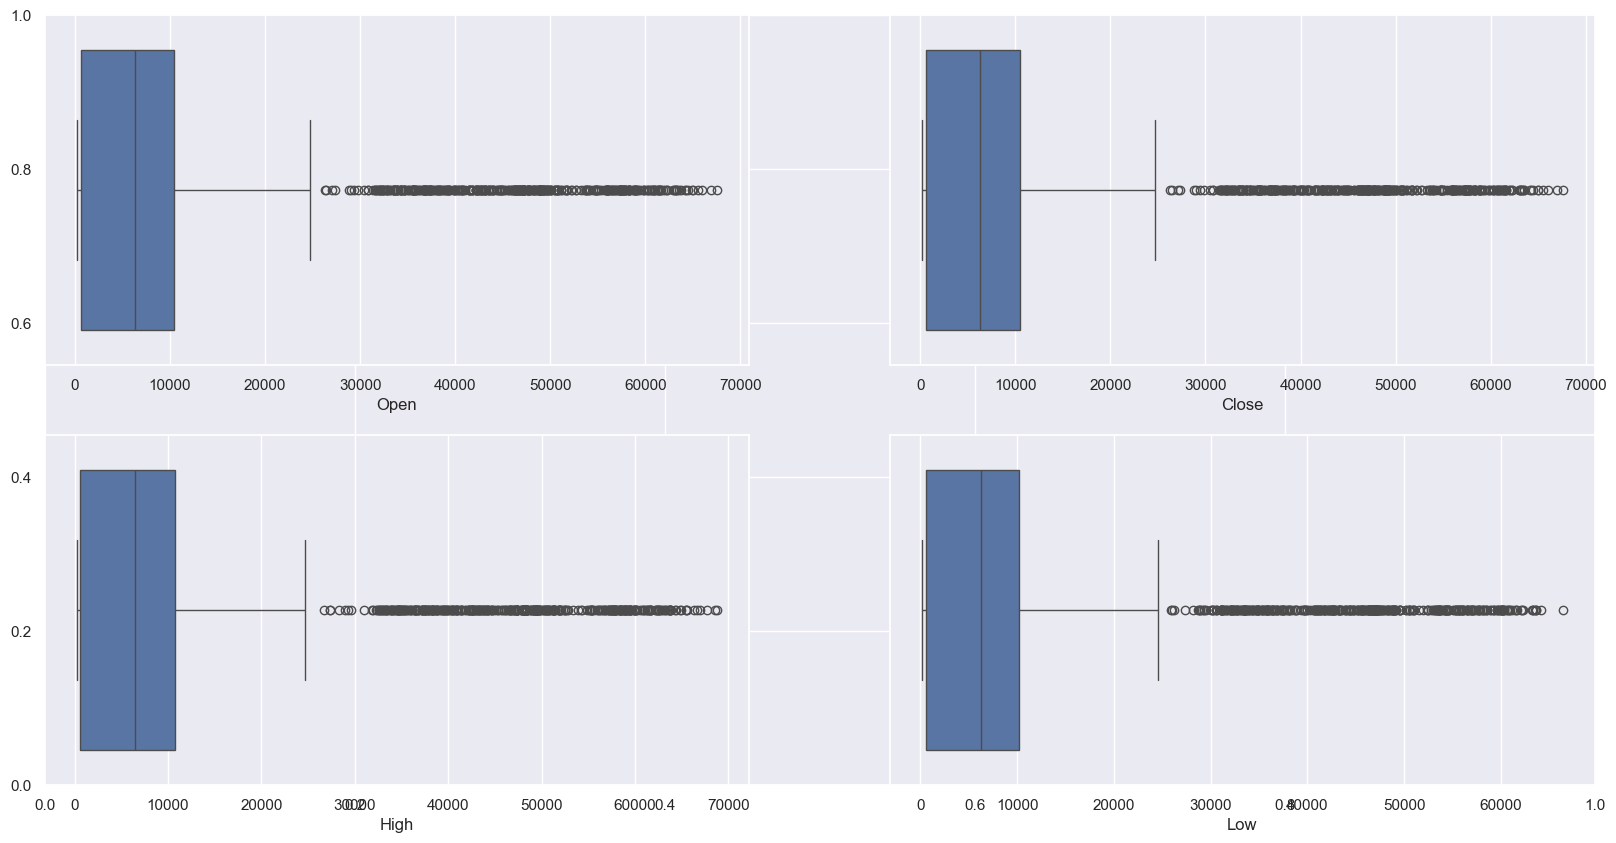

In [15]:
plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(bitcoin_pred[col], orient='h')
plt.show()

There are so many outliers in the data which means that the price of the stock have varied hugely in a very short period of time.

## Feature Engineering

In [16]:
splitted = bitcoin_pred['Date'].str.split('-', expand=True)

bitcoin_pred['year'] = splitted[0].astype('int')
bitcoin_pred['month'] = splitted[1].astype('int')
bitcoin_pred['day'] = splitted[2].astype('int')

bitcoin_pred['Date'] = pd.to_datetime(bitcoin_pred['Date'])

bitcoin_pred.head()

,Date,Open,High,Low,Close,Volume,year,month,day
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21


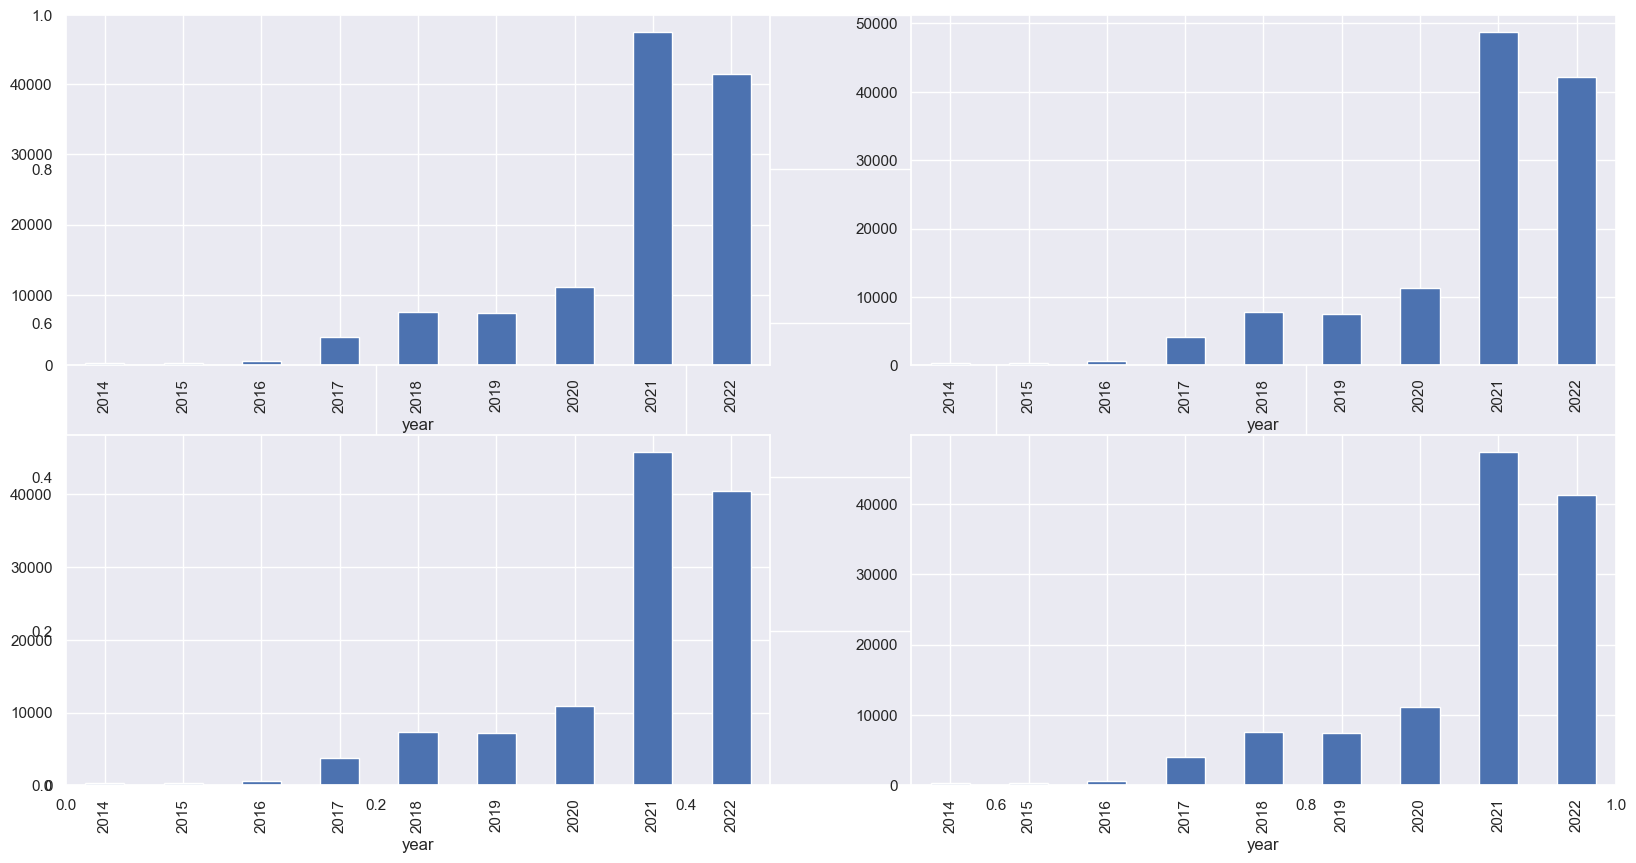

In [17]:
grouped_data = bitcoin_pred.groupby('year').mean()
plt.subplots(figsize=(20, 10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2,2,i+1)
    grouped_data[col].plot.bar()

plt.show()

Here we can observe why there are so many outliers in the data as the price of nitcoin have exploded in the year 2021

## Adding Interactive Features

In [18]:
bitcoin_pred['is_quarter_end'] = np.where(bitcoin_pred['month']%3==0, 1, 0)

bitcoin_pred['open_close'] = bitcoin_pred['Open'] - bitcoin_pred['Close']
bitcoin_pred['low_high'] = bitcoin_pred['Low'] - bitcoin_pred['High']
bitcoin_pred['daily_return'] = bitcoin_pred['Close'].pct_change()
bitcoin_pred['hl_range'] = bitcoin_pred['High'] - bitcoin_pred['Low']
bitcoin_pred['oc_range'] = bitcoin_pred['Close'] - bitcoin_pred['Open']

bitcoin_pred['target'] = np.where(bitcoin_pred['Close'].shift(-1) > bitcoin_pred['Close'], 1, 0)

In [19]:
bitcoin_pred.head()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end,open_close,low_high,daily_return,hl_range,oc_range,target
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,1,8.529999,-15.752014,NaN,15.752014,-8.529999,0
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1,32.419983,-43.755981,-0.071926,43.755981,-32.419983,0
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1,29.307007,-43.302978,-0.069843,43.302978,-29.307007,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1,-14.230988,-33.412994,0.035735,33.412994,14.230988,0
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1,9.263977,-19.244995,-0.024659,19.244995,-9.263977,1


In [20]:
bitcoin_pred.isnull().sum().sort_values(ascending=False)

daily_return      1
Date              0
High              0
Open              0
Close             0
Volume            0
year              0
Low               0
month             0
day               0
open_close        0
is_quarter_end    0
low_high          0
hl_range          0
oc_range          0
target            0
dtype: int64

In [21]:
bitcoin_pred = bitcoin_pred.dropna()

In [22]:
bitcoin_pred.head()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end,open_close,low_high,daily_return,hl_range,oc_range,target
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1,32.419983,-43.755981,-0.071926,43.755981,-32.419983,0
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1,29.307007,-43.302978,-0.069843,43.302978,-29.307007,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1,-14.230988,-33.412994,0.035735,33.412994,14.230988,0
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1,9.263977,-19.244995,-0.024659,19.244995,-9.263977,1
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,24127600,2014,9,22,1,-3.052002,-9.785980,0.008352,9.785980,3.052002,1


In [23]:
bitcoin_pred.describe()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end,open_close,low_high,daily_return,hl_range,oc_range,target
count,2712,2712.000000,2712.000000,2712.000000,2712.000000,2.712000e+03,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000,2712.000000
mean,2018-06-04 12:00:00,11315.040028,11618.402408,10979.435269,11327.921488,1.471003e+10,2017.918879,6.591445,15.737094,0.331121,-12.881460,-638.967139,0.002412,638.967139,12.881460,0.541667
min,2014-09-18 00:00:00,176.897003,211.731003,171.509995,178.102997,5.914570e+06,2014.000000,1.000000,1.000000,0.000000,-7309.636719,-12864.621094,-0.371695,1.028000,-7563.996094,0.000000
25%,2016-07-26 18:00:00,606.478729,609.459014,604.134018,606.724991,8.006163e+07,2016.000000,3.000000,8.000000,0.000000,-75.764283,-596.522217,-0.013140,17.246750,-44.051758,0.000000
50%,2018-06-04 12:00:00,6303.564942,6435.948731,6217.820069,6319.405029,5.104907e+09,2018.000000,7.000000,16.000000,0.000000,-1.601517,-174.247315,0.001996,174.247315,1.601517,1.000000
75%,2020-04-12 06:00:00,10454.205566,10764.747558,10203.775879,10474.648194,2.457311e+10,2020.000000,10.000000,23.000000,1.000000,44.051758,-17.246750,0.018252,596.522217,75.764283,1.000000
max,2022-02-19 00:00:00,67549.734375,68789.625000,66382.062500,67566.828125,3.509679e+11,2022.000000,12.000000,31.000000,1.000000,7563.996094,-1.028000,0.252472,12864.621094,7309.636719,1.000000
std,NaN,16108.052047,16539.054562,15610.142266,16111.983899,2.001797e+10,2.163559,3.526854,8.801335,0.470703,776.208360,1164.323775,0.038835,1164.323775,776.208360,0.498353


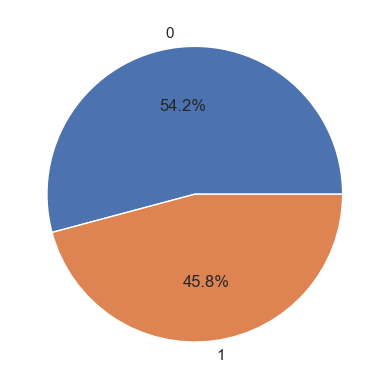

In [24]:
plt.pie(bitcoin_pred['target'].value_counts().values,
        labels=[0,1], autopct='%1.1f%%')

plt.show()

## HeatMap Correlation

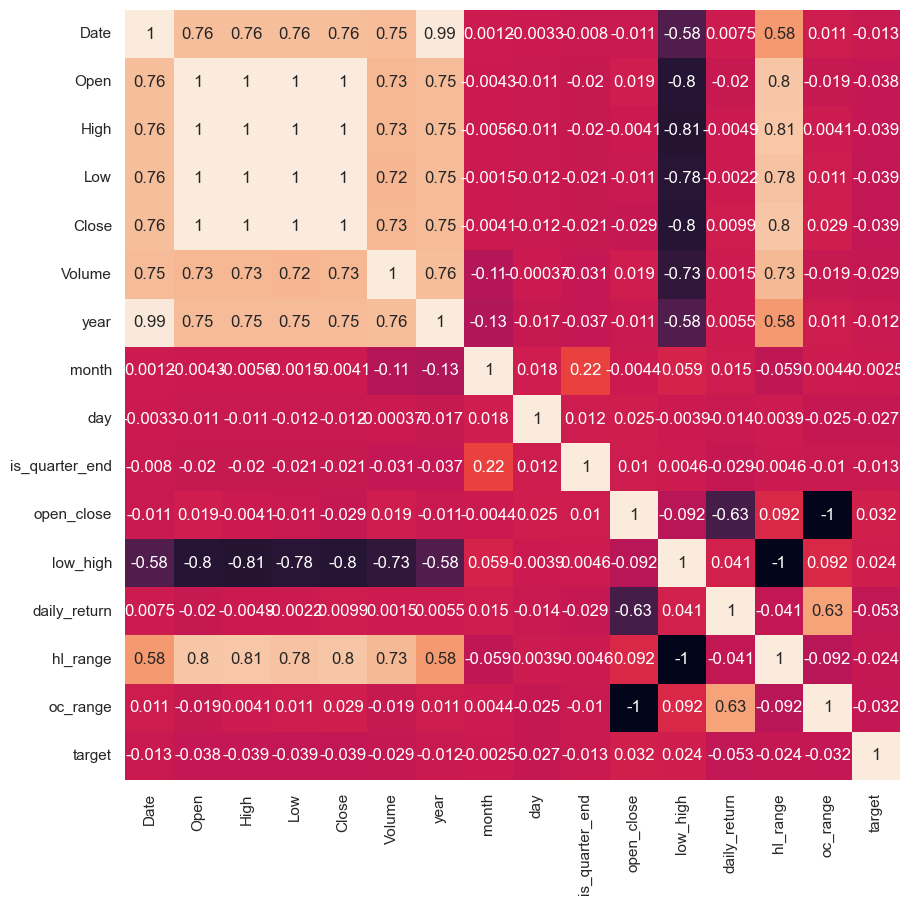

In [25]:
plt.figure(figsize=(10, 10))

sns.heatmap(bitcoin_pred.corr(), annot=True, cbar=False)
plt.show()

From the above `heatmap`, there is a high correlation between ``OHLC``, which is obvious and the added features are not highly correlated with each other or previously provided features which means that we are good to build our model

## Feature Selection and Data Splitting

In [26]:
X = bitcoin_pred.drop(['target', 'Date'], axis=1)
y = bitcoin_pred['target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training, Prediction and Evaluation

### Linear Regression

Scaling `lr` with `StandardScaler` pipeline

In [28]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [29]:
y_pred = pipe.predict(X_test)
print(X_test)

              Open          High           Low         Close       Volume  \
507     386.588989    386.631012    372.386993    376.522003     49249300   
1534   4269.004395   4413.020508   4145.765137   4278.846680   6503347767   
1903   7323.975586   7418.858887   7229.356934   7320.145508  14797485769   
2133   9187.220703   9214.270508   9137.509766   9164.231445  13755604146   
2676  42598.871094  43346.687500  41982.617188  43099.699219  23577403399   
...            ...           ...           ...           ...          ...   
1930   7420.272949   7454.824219   7276.308105   7292.995117  22874131672   
1462   6280.910156   6384.180176   6265.709961   6371.299805   4180090000   
2376  58332.261719  60031.285156  58213.296875  58313.644531  50361731222   
1000   2680.909912   2789.040039   2650.379883   2717.020020   1781200000   
1400   7315.319824   7534.990234   7280.470215   7370.779785   6103410176   

      year  month  day  is_quarter_end  open_close     low_high  daily_retu

### Evaluation 

In [32]:
print('Model Score: ', pipe.score(X_test, y_test))

Model Score:  0.0022587343822678685


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Baseline LinearRegression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline LinearRegression: MAE=0.49, RMSE=0.50, R2=0.00


### Cross Validation Score

In [ ]:
pipe_cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
print(f'Pipeline CV RMSE:  {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).mean():.2f}')

Pipeline CV RMSE:  0.54 +- 0.54
